# Electricity carbon footprint workflow

This notebook reproduces the electricity carbon footprint calculations used in the repository across multiple input-output databases.

## Before you run it

1. Check `paths.yml` and make sure each database path points to a valid local dataset copy.
2. Review `database_properties.py` if you want to change years, versions, systems, or electricity labels.
3. Activate the MARIO "dev" branch where `Database.calc_ghg` is available.

## How to use this notebook

- Run the setup cell first.
- Then run only the database sections you need.
- Each section exports one or more CSV files to `export/`.
- Run the final merge step to build `emission factors/input-output tables/combined_results.csv` in `kg/EUR`.

The helper logic for path resolution, reshaping, and export lives outside the notebook in `common.py`, so the notebook remains focused on the execution workflow.

In [1]:
import warnings
import pandas as pd
import mario

from common import load_config, db_path, emission_factors, export_efs, should_skip
from database_properties import properties

# Keep notebook output readable while preserving MARIO progress messages.
mario.set_log_verbosity('info')
warnings.filterwarnings('ignore')

# How to react when a target CSV already exists in export/:
#   'ask'       -> prompt y/N for each file
#   'skip'      -> always reuse the existing export
#   'overwrite' -> always recompute and replace the export
OVERWRITE_POLICY = 'overwrite'

# Load path templates from paths.yml. `base` is only populated when using the
# older shared-root configuration; with the current explicit-path layout it is None.
cfg, base = load_config()

## EXIOBASE monetary IOT (`ixi` and `pxp`)

This section loops over the EXIOBASE versions, years, and system variants listed in `database_properties.py`.
If a target dataset folder is missing, the notebook attempts to download it before parsing and exporting the electricity-sector results.

In [ ]:
p = properties['exiobase_monetary_iot']
name, table = p['name'], p['table']

for version in p['versions']:
    for year in p['years']:
        for system in p['systems']:
            # EXIOBASE archives are resolved from the configured path template.
            archive = f'IOT_{year}_{system}'
            folder = db_path(
                cfg, base, 'EXIOBASE',
                version=version, table=table, system=system, year=year, archive=archive,
            )
            print(f'\n=== {name} {version} {table} {system} {year} ===')

            # Respect the overwrite policy before doing any download or parsing work.
            if should_skip(name, table, version, year, system, policy=OVERWRITE_POLICY):
                continue

            # Download the dataset only when the expected folder is not already available.
            if not folder.exists():
                folder.parent.mkdir(parents=True, exist_ok=True)
                try:
                    mario.download_exiobase3(
                        path=str(folder.parent),
                        years=year,
                        system=system,
                        table=table,
                        version=version,
                    )
                except Exception as exc:
                    print(f'[skip] download failed: {exc}')
                    continue

            # Parse the database, aggregate GHGs, then keep only electricity sectors.
            try:
                db = mario.parse_exiobase(
                    path=str(folder),
                    table=table,
                    unit='Monetary',
                )
            except Exception as exc:
                print(f'[skip] parse failed: {type(exc).__name__}: {exc}')
                continue

            db_aggr = db.aggregate(f"support/Exiobase_{system}_aggregation.xlsx",ignore_nan=True, levels='Sector', inplace=False)

            db.calc_ghg(profile='exiobase_monetary', inplace=True)
            db_aggr.calc_ghg(profile='exiobase_monetary', inplace=True)

            efs = emission_factors(db, 'Sector', p['labels_list']['non_aggr'][system])
            efs_aggr = emission_factors(db_aggr, 'Sector', p['labels_list']['aggr'][system])

            export_efs(efs, name, table, version, year, system)
            export_efs(efs_aggr, name, table, version, year, system, suffix='aggr')

## EORA26

This section parses the EORA26 release configured in `database_properties.py`, aggregates the GHG satellite accounts, and exports the electricity-related results for the selected year.

In [ ]:
p = properties['eora26']
name, table = p['name'], p['table']

for version in p['versions']:
    for year in p['years']:
        # EORA26 is addressed through the configured full path template.
        path = db_path(cfg, base, 'EORA26', year=year)
        print(f'\n=== {name} {version} {table} {year} ===')

        if should_skip(name, table, version, year, policy=OVERWRITE_POLICY):
            continue

        try:
            db = mario.parse_eora(path=str(path), multi_region=True)
        except Exception as exc:
            print(f'[skip] parse failed: {type(exc).__name__}: {exc}')
            continue

        # # Convert the configured GHG flows into a single electricity-sector export.
        db.calc_ghg(profile='eora', inplace=True)
        efs = emission_factors(
            db, 'Sector', p['labels_list'], ghg_unit='Gg CO2eq'
        )
        export_efs(efs, name, table, version, year)

## EMERGING

This section runs the EMERGING dataset with MARIO's inverse-based compute method, then exports the electricity-sector footprint results for the configured year.

In [ ]:
# EMERGING is run with the inverse method before parsing the database.
for version in p['versions']:
    p = properties[f'emerging_v{version}']
    name, table = p['name'], p['table']

    for year in p['years']:
        path = db_path(cfg, base, f'EMERGING_v{version}', year=year)
        print(f'\n=== {name} {version} {table} {year} ===')

        if should_skip(name, table, version, year, policy=OVERWRITE_POLICY):
            continue

        try:
            db = mario.parse_emerging(path=str(path), year=year)
        except Exception as exc:
            print(f'[skip] parse failed: {type(exc).__name__}: {exc}')
            continue

        # The EMERGING profile returns Mt CO2eq before later unit harmonisation.
        db.calc_ghg(profile='emerging', inplace=True)
        efs = emission_factors(
            db, 'Sector', p['labels_list'], ghg_unit='Mt CO2eq'
        )
        export_efs(efs, name, table, version, year)

## GTAP

In [ ]:
p = properties[f'gtap']
name, table = p['name'], p['table']

for version in p['versions']:

    for year in p['years']:
        path = db_path(cfg, base, f'GTAP', version=version, year=year)
        print(f'\n=== {name} {version} {table} {year} ===')

        if should_skip(name, table, version, year, policy=OVERWRITE_POLICY):
            continue

        try:
            db = mario.parse_gtap(path=str(path))
        except Exception as exc:
            print(f'[skip] parse failed: {type(exc).__name__}: {exc}')
            continue

        db.aggregate(f"support/GTAP_aggregation_{year}.xlsx",ignore_nan=True, levels=['Sector','Satellite account'])

        db.calc_ghg(gwp={'CO2':1, 'CH4':29.7, 'N2O':264.8}, inplace=True)
        efs = emission_factors(
            db, 'Sector', p['labels_list'], ghg_unit='Mt CO2eq'
        )
        export_efs(efs, name, table, version, year)

In [ ]:
db.calc_ghg(gwp={'CO2':1, 'CH4':29.7, 'N2O':264.8}, inplace=True)
efs = emission_factors(
    db, 'Sector', p['labels_list'], ghg_unit='Mt CO2eq'
)
export_efs(efs, name, table, version, year)

## GLORIA

GLORIA exposes electricity information in both `Activity` and `Commodity` dimensions. This section computes GHGs for both views, renames the active dimension to `Sector`, and concatenates the results into one export table.

In [ ]:
p = properties['gloria']
name, table = p['name'], p['table']

for version in p['versions']:
    for year in p['years']:
        path = db_path(cfg, base, 'GLORIA', year=year)
        print(f'\n=== {name} {version} {table} {year} ===')

        if should_skip(name, table, version, year, policy=OVERWRITE_POLICY):
            continue

        try:
            db = mario.parse_gloria(path=str(path), year=year)
        except Exception as exc:
            print(f'[skip] parse failed: {type(exc).__name__}: {exc}')
            continue

        db.calc_ghg(profile='gloria', inplace=True)

        # GLORIA stores relevant electricity labels under two dimensions. Rename
        # each active dimension to `Sector` before combining the results.
        efs = pd.concat([
            emission_factors(db, level, labels).rename(columns={level: 'Sector'}, ghg_unit='kilotonnes')
            for level, labels in p['labels_list'].items()
        ], axis=0, ignore_index=True)

        export_efs(efs, name, table, version, year)

---
## Query US and EU countries and convert to physical units


In [2]:
import os
from datetime import datetime
from forex_python.converter import CurrencyRates
import country_converter as coco
cc = coco.CountryConverter()

regions = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'GR', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK','US']
prices = pd.read_excel('support/Electricity_Prices.xlsx')

folder = 'emission factors/input-output tables/monetary'
files = os.listdir(folder)

monetary_efs_IO = pd.concat(
    (pd.read_csv(os.path.join(folder, f)) for f in files),
    axis=0,
)

monetary_efs_IO['Region'] = cc.convert(names=monetary_efs_IO['Region'], src='ISO3', to='ISO2', not_found=None)
monetary_efs_IO = monetary_efs_IO.query("Region in @regions")

_rates = CurrencyRates()
_cache = {}

def usd_to_eur(year):
    year = int(year)
    if year not in _cache:
        _cache[year] = _rates.get_rate('USD', 'EUR', datetime(year, 6, 15))
    return _cache[year]


def to_kg_per_eur(row):
    unit, value, year = row['Unit'], row['Value'], row['Year']
    if unit == 'kg/EUR':
        return value
    if unit == 'kg/M.EUR' or unit == 'kg CO2eq/M.EUR':  
        return value / 1_000_000
    if unit in {'Mt CO2eq/current million US$', 'kilotonnes/current 000 US$', 'Mt CO2eq/M USD'}:
        return value * 1_000 / usd_to_eur(year)
    if unit == 'Gg CO2eq/current 000 US$':
        return value * 1_000 / usd_to_eur(year)
    return value


monetary_efs_IO['Value'] = monetary_efs_IO.apply(to_kg_per_eur, axis=1)
monetary_efs_IO['Unit'] = 'kg/EUR'

monetary_efs_IO['Type'] = 'Monetary'

In [3]:
price_lookup = prices[['Region', 'Year', 'Value']].rename(columns={'Value': 'Price'})

physical_efs_IO = monetary_efs_IO.merge(
    price_lookup,
    on=['Region', 'Year'],
    how='left',
    validate='many_to_one'
)

physical_efs_IO['Value'] = physical_efs_IO['Value'] * physical_efs_IO['Price'] * 1000
physical_efs_IO['Unit'] = 'g/kWh'
physical_efs_IO = physical_efs_IO.drop(columns='Price')

## Parse emission factors from non-IO sources and append all together

In [4]:
physical_efs_oth = pd.read_excel("emission factors/other sources.xlsx")
physical_efs = pd.concat([physical_efs_IO, physical_efs_oth], axis=0, ignore_index=True)
physical_efs.to_csv('emission factors/physical_efs.csv', index=False)

## Generate plot (Figure 2)

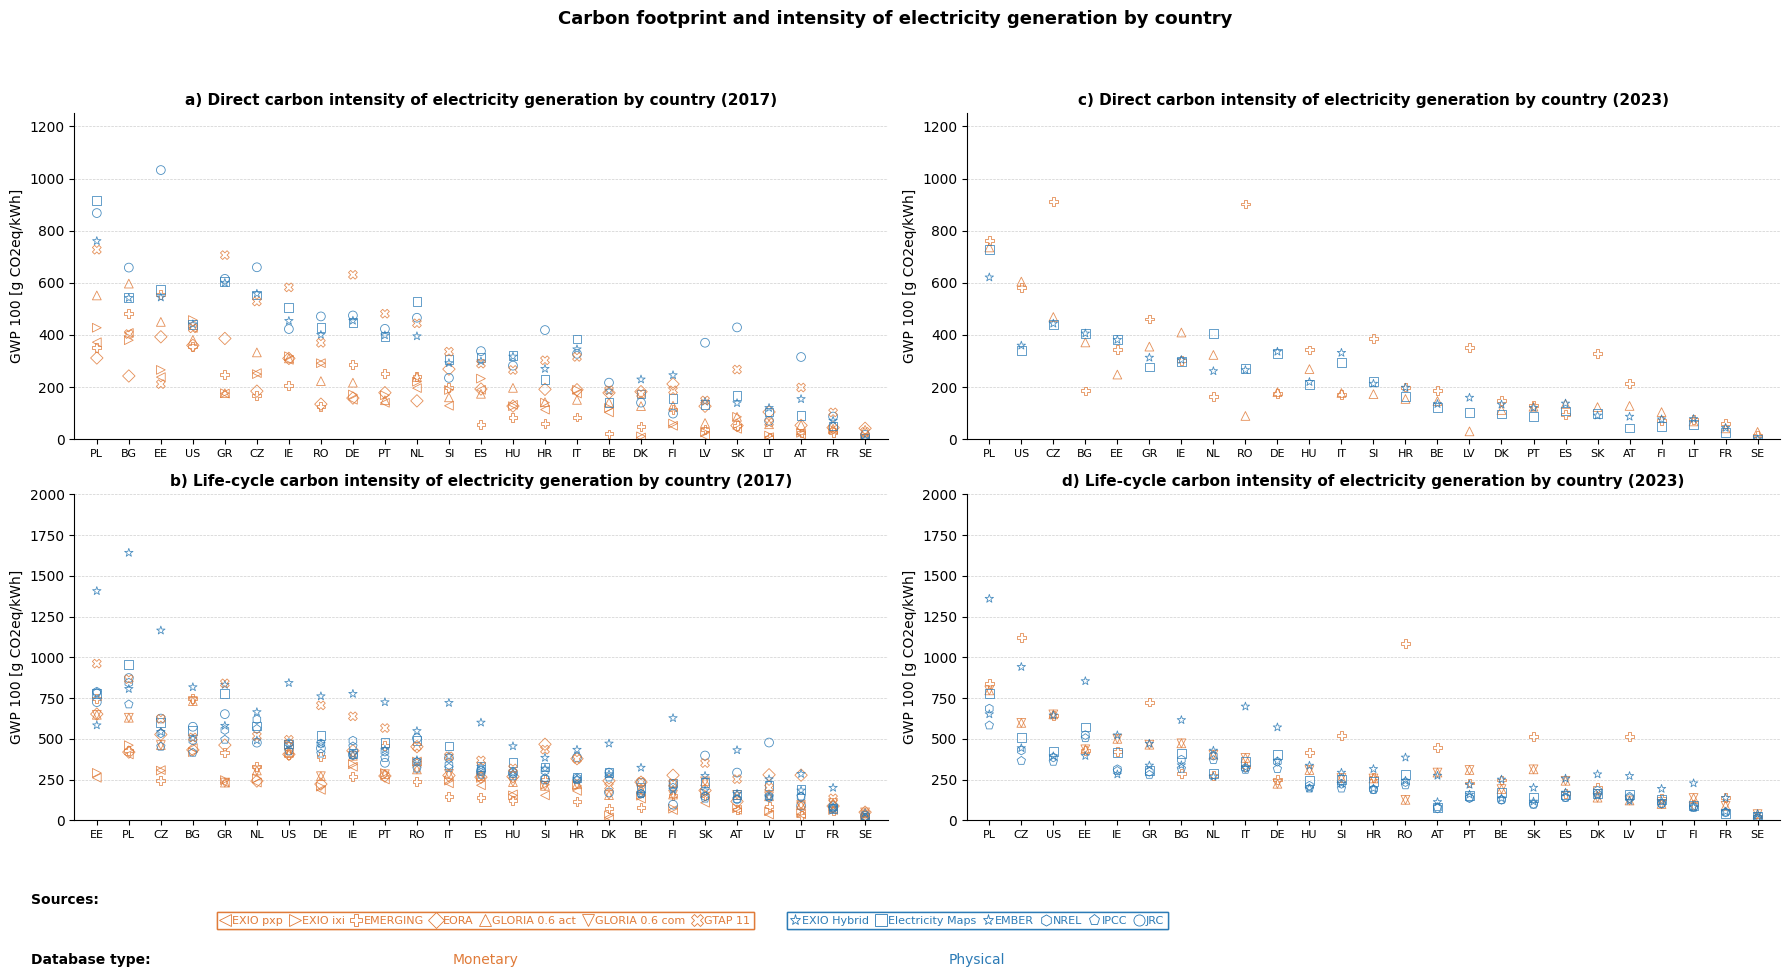

In [5]:
import importlib
import plots
import pandas as pd

importlib.reload(plots)
from plots import Config, load_inter_font, plot_physical_efs

physical_efs = pd.read_csv('emission factors/physical_efs.csv')

cfg = Config()

plot_df, country_order, fig = plot_physical_efs(physical_efs, cfg)

In [6]:
from pathlib import Path

output_dir = Path("plots/figures")
output_dir.mkdir(parents=True, exist_ok=True)
output_stem = output_dir / "figure_2_electricity_carbon_footprint"
save_dpi = 600

fig.savefig(output_stem.with_suffix(".svg"), bbox_inches="tight")
fig.savefig(output_stem.with_suffix(".jpg"), dpi=save_dpi, bbox_inches="tight", pil_kwargs={"quality": 95})
fig.savefig(output_stem.with_suffix(".tiff"), dpi=save_dpi, bbox_inches="tight")

print("Saved:")
print(output_stem.with_suffix(".svg"))
print(output_stem.with_suffix(".jpg"))
print(output_stem.with_suffix(".tiff"))

Saved:
plots/figures/figure_2_electricity_carbon_footprint.svg
plots/figures/figure_2_electricity_carbon_footprint.jpg
plots/figures/figure_2_electricity_carbon_footprint.tiff
